In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [66]:
df=pd.read_csv("boston.csv")

In [67]:
df

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48,22.0


In [68]:
df.dropna(inplace=True)

In [69]:
X=df.copy()
y=df["MEDV"]

In [70]:
X.drop("MEDV",inplace=True,axis=1)

In [71]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.2,random_state=42)

In [72]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [73]:
from sklearn.linear_model import LassoCV

In [74]:
model = LassoCV(random_state=42, max_iter=5000)
model.fit(X_train, y_train)

print("Best alpha selected:", model.alpha_)

Best alpha selected: 0.006863892263379668


In [75]:
y_pred = model.predict(X_test)
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test,y_pred)
from sklearn.metrics import r2_score
print("R2 Score:", r2_score(y_test, y_pred))
mae

R2 Score: 0.6683883969336302


3.183406999670042

In [76]:
print(pd.Series(model.coef_,index=X.columns))

CRIM      -0.983042
ZN         0.662207
INDUS      0.215572
CHAS       0.719674
NOX       -1.978859
RM         3.149505
AGE       -0.160356
DIS       -3.033683
RAD        2.127566
TAX       -1.643649
PTRATIO   -2.025009
B          1.121376
LSTAT     -3.610072
dtype: float64


Text(0, 0.5, 'Coeff Values')

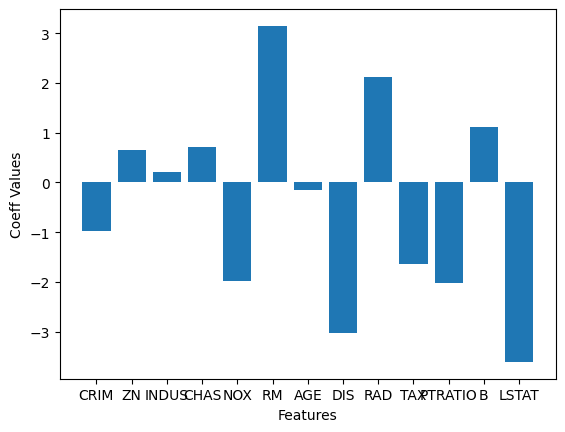

In [77]:
coef=model.coef_
plt.bar(X.columns,coef)
plt.xlabel("Features")
plt.ylabel("Coeff Values")

Alpha = 0.0010 | Coefficients = [-0.99935912  0.69130002  0.26893579  0.71887992 -2.01602945  3.14586767
 -0.17377772 -3.07491317  2.23334727 -1.74899938 -2.03590048  1.12837163
 -3.61140283]
Alpha = 0.0013 | Coefficients = [-0.99859602  0.68994229  0.2664219   0.7189182  -2.01429372  3.14603574
 -0.1731483  -3.07299628  2.22838405 -1.74405234 -2.03538804  1.12804225
 -3.61133942]
Alpha = 0.0016 | Coefficients = [-0.9976208   0.68821234  0.26321915  0.71896649 -2.01207217  3.1462496
 -0.17234356 -3.070548    2.22205094 -1.73774618 -2.03473257  1.12762269
 -3.61126281]
Alpha = 0.0021 | Coefficients = [-0.99638743  0.68600822  0.25916201  0.71902641 -2.0092589   3.14652139
 -0.17132225 -3.06742694  2.2140394  -1.72975776 -2.03390747  1.12709073
 -3.61116123]
Alpha = 0.0026 | Coefficients = [-0.99479882  0.6831946   0.25397594  0.71910383 -2.00563744  3.1468719
 -0.17001548 -3.06343439  2.20374883 -1.7195231  -2.03284223  1.12641138
 -3.61104109]
Alpha = 0.0034 | Coefficients = [-0.992793

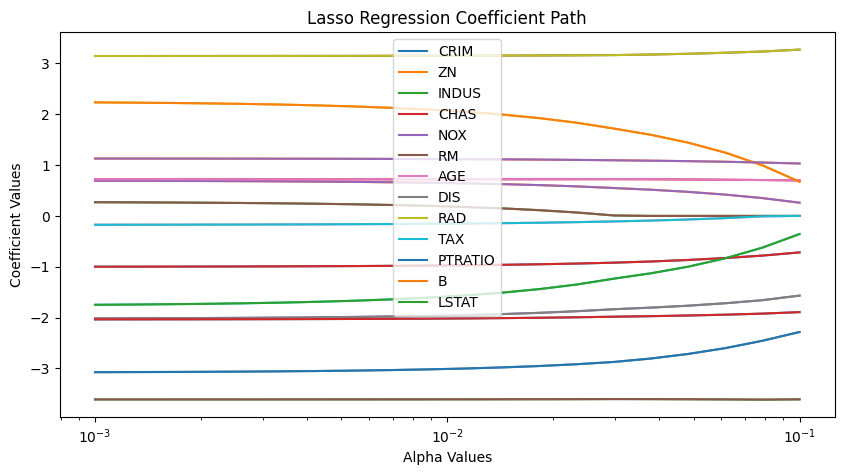

In [78]:
alphas = np.logspace(-3,-1,20)
coefficients_path = []
from sklearn.linear_model import Lasso
for alpha_value in alphas:
  lasso = Lasso(alpha=alpha_value,max_iter=5000)
  lasso.fit(X_train,y_train)
  coefficients_path.append(lasso.coef_)

  print(f"Alpha = {alpha_value:.4f} | Coefficients = {lasso.coef_}")

coefficients_path = np.array(coefficients_path)

plt.figure(figsize=(10,5))
plt.plot(alphas,coefficients_path)
plt.xscale("log")
plt.plot(alphas,coefficients_path)
plt.xlabel("Alpha Values")
plt.ylabel("Coefficient Values")
plt.title("Lasso Regression Coefficient Path")
plt.legend(X.columns)
plt.show()